In [ ]:
# CELL 1: Setup and Mount
from google.colab import drive
import os

# 1. Mount Google Drive to save weights safely
drive.mount('/content/drive')

# 2. Create checkpoint directories on Drive
os.makedirs('/content/drive/MyDrive/FYP_PROJECT/FYP_Checkpoints/AdaLOLIE', exist_ok=True)
os.makedirs('/content/drive/MyDrive/FYP_PROJECT/FYP_Checkpoints/YOLO_Runs', exist_ok=True)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
# Install the required packages for YOLO and Comet
!pip install ultralytics comet_ml torch torchvision

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 53.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 786.2/786.2 kB 89.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 116.9 MB/s eta 0:00:00
  Attempting uninstall: python-box
    Found existing installation: python-box 7.4.1
    Uninstalling python-box-7.4.1:
      Successfully uninstalled python-box-7.4.1


In [ ]:
# Unzip DsDPM_YOLO_Lightweight Dataset
print("📦 Unzipping DsDPM_YOLO_Lightweight to high-speed Colab storage...")
!unzip -q "/content/drive/MyDrive/FYP_PROJECT/Data/DsDPM_YOLO_Lightweight.zip" -d "/content/"

print("✅ Data Extraction Complete!")

📦 Unzipping DsDPM_YOLO_Lightweight to high-speed Colab storage...
✅ Data Extraction Complete!


In [ ]:
!pip install pyunpack patool

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 88.6/88.6 kB 3.9 MB/s eta 0:00:00


In [ ]:
!unzip -q "/content/drive/MyDrive/FYP_PROJECT/Data/Lightweight_DsDPM_Unified_V3.zip" -d /content/

In [ ]:
# Unzip MiningMix_Unified Dataset
print("📦 Unzipping MiningMix_Unified to high-speed Colab storage...")
!unzip -q "/content/drive/MyDrive/FYP_PROJECT/Data/MiningMix_Unified.zip" -d "/content/"

print("✅ Data Extraction Complete!")

📦 Unzipping MiningMix_Unified to high-speed Colab storage...
✅ Data Extraction Complete!


In [ ]:
from google.colab import userdata

!export COMET_API_KEY=BDA8b7jJyTFvOSAbOQnIOIOpf

### Experiment 4: Combined Balancing (Focal Loss + Custom Class Penalties + Dynamic Image Sampling)

In [ ]:
import glob
import random
from collections import defaultdict
from ultralytics import YOLO

# Initialize Comet globally so YOLOv8 automatically detects it
os.environ["COMET_API_KEY"] = "BDA8b7jJyTFvOSAbOQnIOIOpf"
comet_ml.login(project_name="YOLO-Mining-Safety")

RUN_NAME = "exp4_custom_sampling"
CHECKPOINT_PATH = f"/content/drive/MyDrive/FYP_PROJECT/FYP_Checkpoints/YOLO_Runs/{RUN_NAME}/weights/last.pt"

LABEL_DIR = "/content/DsDPM_YOLO_Lightweight/labels/train"
class_to_images = defaultdict(list)

print("⚖️ Calculating data-driven class distribution...")
for label_file in glob.glob(os.path.join(LABEL_DIR, "*.txt")):
    with open(label_file) as f:
        classes = {int(line.split()[0]) for line in f if line.strip()}

    img_path = label_file.replace("labels", "images").replace(".txt", ".jpg")
    for c in classes:
        class_to_images[c].append(img_path)

# --- PURE DATA-DRIVEN OVERSAMPLING ---
# 1. Find the size of the majority class dynamically
max_class_size = max(len(imgs) for imgs in class_to_images.values())
print(f"📈 Majority class has {max_class_size} images. Balancing dataset...")

balanced_images = []
# 2. Oversample all classes to mathematically match the majority
for c, imgs in class_to_images.items():
    # random.choices allows duplicate sampling of rare images
    balanced_images.extend(random.choices(imgs, k=max_class_size))

# 3. Shuffle the giant list so YOLO doesn't train on the same class 10,000 times in a row
random.shuffle(balanced_images)

with open("/content/DsDPM_YOLO_Lightweight/balanced_train.txt", "w") as f:
    f.write("\n".join(balanced_images))

print(f"✅ Generated dynamic text dataloader with {len(balanced_images)} total images!")

# --- YAML GENERATION ---
yaml_content = """
path: /content/DsDPM_YOLO_Lightweight
train: balanced_train.txt
val: images/val
names:
  0: coal_miner
  1: drill_pipe
  2: drill_rig
  3: interaction_between_miner_and_drill_pipe
  4: mining_helmet
"""
with open("/content/DsDPM_YOLO_Lightweight/balanced_data.yaml", "w") as f:
    f.write(yaml_content.strip())

# --- HARDWARE-OPTIMIZED TRAINING LOOP ---
if os.path.exists(CHECKPOINT_PATH):
    print(f"🔄 Checkpoint found for {RUN_NAME}! Resuming training...")
    model = YOLO(CHECKPOINT_PATH)
    model.train(resume=True)
else:
    print(f"🆕 No checkpoint found. Starting {RUN_NAME} from scratch...")
    model = YOLO("yolov8n.pt")
    model.train(
      data="/content/DsDPM_YOLO_Lightweight/balanced_data.yaml",
      imgsz=640,
      epochs=100,
      batch=32,
      fraction=0.20,
      workers=8,
      cache=True,
      save_period=10,
      patience=20,
      optimizer='AdamW',
      cos_lr=True,
      project="/content/drive/MyDrive/FYP_PROJECT/FYP_Checkpoints/YOLO_Runs",
      name=RUN_NAME
    )

# 3. TELL COMET THE RUN IS OVER
print("✅ Training complete! Syncing final weights to Comet...")
comet_ml.end()

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
⚖️ Calculating data-driven class distribution...
📈 Majority class has 62308 images. Balancing dataset...
✅ Generated dynamic text dataloader with 124616 total images!
🔄 Checkpoint found for exp4_custom_sampling! Resuming training...
Ultralytics 8.4.24 🚀 Python-3.12.12 torch-2.10.0+cu128 CUDA:0 (NVIDIA L4, 22563MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=32, bgr=0.0, box=7.5, cache=True, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=True, cutmix=0.0, data=/content/DsDPM_YOLO_Lightweight/balanced_data.yaml, degrees=0.0, deterministic=True, devic

COMET WARNING: As you are running in a Jupyter environment, you will need to call `experiment.end()` when finished to ensure all metrics and code are logged before exiting.
COMET INFO: Experiment is live on comet.com https://www.comet.com/thaveesha-sonnadara/yolo-mining-safety/ec4d7bba375e4b7abe26cc25353e99a9

COMET INFO: Couldn't find a Git repository in '/content' nor in any parent directory. Set `COMET_GIT_DIRECTORY` if your Git Repository is elsewhere.



                   from  n    params  module                                       arguments                     
  0                  -1  1       464  ultralytics.nn.modules.conv.Conv             [3, 16, 3, 2]                 
  1                  -1  1      4672  ultralytics.nn.modules.conv.Conv             [16, 32, 3, 2]                
  2                  -1  1      7360  ultralytics.nn.modules.block.C2f             [32, 32, 1, True]             
  3                  -1  1     18560  ultralytics.nn.modules.conv.Conv             [32, 64, 3, 2]                
  4                  -1  2     49664  ultralytics.nn.modules.block.C2f             [64, 64, 2, True]             
  5                  -1  1     73984  ultralytics.nn.modules.conv.Conv             [64, 128, 3, 2]               
  6                  -1  2    197632  ultralytics.nn.modules.block.C2f             [128, 128, 2, True]           
  7                  -1  1    295424  ultralytics.nn.modules.conv.Conv             [128

COMET INFO: ---------------------------------------------------------------------------------------
COMET INFO: Comet.ml Experiment Summary
COMET INFO: ---------------------------------------------------------------------------------------
COMET INFO:   Data:
COMET INFO:     display_summary_level : 1
COMET INFO:     name                  : copper_peach_7714
COMET INFO:     url                   : https://www.comet.com/thaveesha-sonnadara/yolo-mining-safety/ec4d7bba375e4b7abe26cc25353e99a9
COMET INFO:   Metrics [count] (min, max):
COMET INFO:     loss [3112]               : (58785.53125, 356107.4375)
COMET INFO:     lr/pg0 [41]               : (0.0009559511573409196, 0.0062810149414660316)
COMET INFO:     lr/pg1 [41]               : (0.0009559511573409196, 0.0062810149414660316)
COMET INFO:     lr/pg2 [41]               : (0.0009559511573409196, 0.0062810149414660316)
COMET INFO:     metrics/mAP50(B) [41]     : (0.26418, 0.26735)
COMET INFO:     metrics/mAP50-95(B) [41]  : (0.2032, 0.20

✅ Training complete! Syncing final weights to Comet...


### Optimized YOLOv8 Training - v1

In [ ]:
import comet_ml
from ultralytics import YOLO

comet_ml.login(project_name="DsDPM66_Yolov8s_Mining_Safety")

# 1. Load the YOLOv8s model (Small has better capacity for 6 classes than Nano)
model = YOLO('yolov8s.pt')

# 2. Train with full dataset utilization
results = model.train(
    data='/content/Lightweight_DsDPM_Unified_V2/data.yaml',
    epochs=100,
    imgsz=640,
    batch=32,
    patience=50,
    mixup=0.2,
    copy_paste=0.1,
    hsv_v=0.4,    # Increase brightness augmentation
    noise=0.1,    # Help the model handle sensor noise in low light
    mosaic=1.0,   # Keep mosaic high to help with small objects
    fraction=1.0,            # Use 100% of the unified data
    optimizer='AdamW',
    lr0=0.001,                # Standard initial learning rate
    augment=True,            # Essential for mining scenes
    close_mosaic=15,          # Disable mosaic in last 10 epochs for accuracy refinement
    save_period=1,
    project='/content/drive/MyDrive/FYP_PROJECT/FYP_Checkpoints/YOLO_Runs',
    name='v8s_unified_6class_640',
    device=0
)

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
Please paste your Comet API key from https://www.comet.com/api/my/settings/
(api key may not show as you type)


COMET INFO: Valid Comet API Key saved in /content/drive/MyDrive/.comet.config (set COMET_CONFIG to change where it is saved).


Ultralytics 8.4.31 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (NVIDIA L4, 22563MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=True, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/Lightweight_DsDPM_Unified_V2/data.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=100, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8s.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=v8s_unified_6class_640, nbs=64, nms=False, opset=None, optimize=False, optimizer=SGD, overlap_mask

COMET WARNING: As you are running in a Jupyter environment, you will need to call `experiment.end()` when finished to ensure all metrics and code are logged before exiting.
COMET INFO: Experiment is live on comet.com https://www.comet.com/thaveesha-sonnadara/dsdpm66-yolov8s-mining-safety/9f337bc533e543999e0e6a45213d8406

COMET INFO: Couldn't find a Git repository in '/content' nor in any parent directory. Set `COMET_GIT_DIRECTORY` if your Git Repository is elsewhere.


Overriding model.yaml nc=80 with nc=6

                   from  n    params  module                                       arguments                     
  0                  -1  1       928  ultralytics.nn.modules.conv.Conv             [3, 32, 3, 2]                 
  1                  -1  1     18560  ultralytics.nn.modules.conv.Conv             [32, 64, 3, 2]                
  2                  -1  1     29056  ultralytics.nn.modules.block.C2f             [64, 64, 1, True]             
  3                  -1  1     73984  ultralytics.nn.modules.conv.Conv             [64, 128, 3, 2]               
  4                  -1  2    197632  ultralytics.nn.modules.block.C2f             [128, 128, 2, True]           
  5                  -1  1    295424  ultralytics.nn.modules.conv.Conv             [128, 256, 3, 2]              
  6                  -1  2    788480  ultralytics.nn.modules.block.C2f             [256, 256, 2, True]           
  7                  -1  1   1180672  ultralytics

     41/100      4.08G     0.7378      1.275     0.9968         14        640: 100% ━━━━━━━━━━━━ 3870/3870 6.3it/s 10:12
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 536/536 6.7it/s 1:20
                   all      17136      21162      0.404      0.276      0.222      0.187

      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
     42/100      4.08G     0.7488      1.272          1          5        640: 100% ━━━━━━━━━━━━ 3870/3870 6.3it/s 10:12
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 536/536 6.7it/s 1:20
                   all      17136      21162      0.404      0.275      0.223      0.188

      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
     43/100      4.08G     0.7406      1.264     0.9987          5        640: 100% ━━━━━━━━━━━━ 3870/3870 6.3it/s 10:12
                 Class     Images  Instance

     65/100      4.08G     0.6774      1.176     0.9687          9        640: 100% ━━━━━━━━━━━━ 3870/3870 6.3it/s 10:12
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 536/536 6.7it/s 1:20
                   all      17136      21162      0.424      0.276      0.234      0.199

      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
     66/100      4.08G     0.6703      1.171      0.966          7        640: 100% ━━━━━━━━━━━━ 3870/3870 6.3it/s 10:13
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 536/536 6.7it/s 1:20
                   all      17136      21162      0.425      0.275      0.234        0.2

      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
     67/100      4.08G      0.668      1.161     0.9637          7        640: 100% ━━━━━━━━━━━━ 3870/3870 6.3it/s 10:12
                 Class     Images  Instance

### Optimized YOLOv8 Training - v2

In [ ]:
import comet_ml
from ultralytics import YOLO

comet_ml.login(project_name="DsDPM66_Yolov8s_Mining_Safet_Optimised")

# 1. Load the YOLOv8s model (Small has better capacity for 6 classes than Nano yet lightweight)
model = YOLO('yolov8s.pt')

# 2. Train with full dataset utilization
results = model.train(
    data='/content/Lightweight_DsDPM_Unified_V3/data_colab.yaml',
    # CORE TRAINING
    epochs=100,                 # increased (100 → 200)
    imgsz=768,
    batch=16,
    patience=50,               # early stopping
    # OPTIMIZER
    optimizer='SGD',
    lr0=0.01,
    lrf=0.01,                  # final LR fraction
    momentum=0.937,
    weight_decay=0.0005,
    # LR SCHEDULING
    cos_lr=True,               # cosine decay (important)
    # AUGMENTATION (CRITICAL FOR mAP)
    hsv_h=0.015,
    hsv_s=0.7,
    hsv_v=0.4,
    degrees=5.0,
    translate=0.1,
    scale=0.5,
    shear=2.0,
    fliplr=0.5,
    flipud=0.0,
    mosaic=1.0,                # strong early training
    mixup=0.2,                 # improves generalization
    copy_paste=0.1,            # helps rare classes
    close_mosaic=15,           # longer stabilization phase
    # REGULARIZATION
    label_smoothing=0.1,
    # PERFORMANCE
    workers=8,
    amp=True,                  # mixed precision
    # LOGGING
    project='/content/drive/MyDrive/FYP_PROJECT/FYP_Checkpoints/YOLO_Runs',
    name='v8s_optimized_6class_768_100e',
    device=0,
    save_period=5
)

### Resume Training

In [ ]:
from ultralytics import YOLO

# Load the last.pt checkpoint
model = YOLO('/content/drive/MyDrive/FYP_PROJECT/FYP_Checkpoints/YOLO_Runs/v8s_optimized_6class_768_100e2/weights/last.pt')

# Resume training
results = model.train(resume=True)


Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
Ultralytics 8.4.33 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (NVIDIA RTX PRO 6000 Blackwell Server Edition, 97250MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=15, cls=0.5, compile=False, conf=None, copy_paste=0.1, copy_paste_mode=flip, cos_lr=True, cutmix=0.0, data=/content/Lightweight_DsDPM_Unified_V3/data_colab.yaml, degrees=5.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=100, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, hal

COMET WARNING: To get all data logged automatically, import comet_ml before the following modules: torch.
COMET WARNING: As you are running in a Jupyter environment, you will need to call `experiment.end()` when finished to ensure all metrics and code are logged before exiting.
COMET INFO: Experiment is live on comet.com https://www.comet.com/thaveesha-sonnadara/content-drive-mydrive-fyp-project-fyp-checkpoints-yolo-runs/458d18855262442ea5f5241858c27f16

COMET INFO: Couldn't find a Git repository in '/content' nor in any parent directory. Set `COMET_GIT_DIRECTORY` if your Git Repository is elsewhere.



                   from  n    params  module                                       arguments                     
  0                  -1  1       928  ultralytics.nn.modules.conv.Conv             [3, 32, 3, 2]                 
  1                  -1  1     18560  ultralytics.nn.modules.conv.Conv             [32, 64, 3, 2]                
  2                  -1  1     29056  ultralytics.nn.modules.block.C2f             [64, 64, 1, True]             
  3                  -1  1     73984  ultralytics.nn.modules.conv.Conv             [64, 128, 3, 2]               
  4                  -1  2    197632  ultralytics.nn.modules.block.C2f             [128, 128, 2, True]           
  5                  -1  1    295424  ultralytics.nn.modules.conv.Conv             [128, 256, 3, 2]              
  6                  -1  2    788480  ultralytics.nn.modules.block.C2f             [256, 256, 2, True]           
  7                  -1  1   1180672  ultralytics.nn.modules.conv.Conv             [256

COMET INFO: ---------------------------------------------------------------------------------------
COMET INFO: Comet.ml Experiment Summary
COMET INFO: ---------------------------------------------------------------------------------------
COMET INFO:   Data:
COMET INFO:     display_summary_level : 1
COMET INFO:     name                  : improved_lumber_2551
COMET INFO:     url                   : https://www.comet.com/thaveesha-sonnadara/content-drive-mydrive-fyp-project-fyp-checkpoints-yolo-runs/458d18855262442ea5f5241858c27f16
COMET INFO:   Metrics [count] (min, max):
COMET INFO:     lr/pg0 [30]               : (0.0001024425261896289, 0.002016110084417766)
COMET INFO:     lr/pg1 [30]               : (0.0001024425261896289, 0.002016110084417766)
COMET INFO:     lr/pg2 [30]               : (0.0001024425261896289, 0.002016110084417766)
COMET INFO:     metrics/mAP50(B) [30]     : (0.69573, 0.70598)
COMET INFO:     metrics/mAP50-95(B) [30]  : (0.58006, 0.59207)
COMET INFO:     metrics/

### AdaLOLIE Custom Training

In [ ]:
# AdaLOLIE Custom Training
import comet_ml
import os

# Import ONLY the wrapper (it handles the model and loss internally)
from train import TrainScript

# Initialize Comet
experiment = comet_ml.start(project_name="AdaLOLIE-Mining-Safety_10")

# Initialize the trainer wrapper
trainer = TrainScript(exp_obj=experiment)

# --- OVERRIDE PATHS FOR COLAB ---
# Tell the script to look at the fast local storage
trainer.TRAIN_PATH = "/content/MiningMix_Unified/train"
trainer.VAL_PATH = "/content/MiningMix_Unified/val"
trainer.TEST_PATH = "/content/MiningMix_Unified/test"
trainer.SAVE_DIR = "/content/drive/MyDrive/FYP_PROJECT/FYP_Checkpoints/AdaLOLIE_10"

print("🚀 Starting AdaLOLIE Training Pipeline...")
trainer.train()

# Securely upload final weights
experiment.end()

COMET WARNING: As you are running in a Jupyter environment, you will need to call `experiment.end()` when finished to ensure all metrics and code are logged before exiting.
COMET INFO: Experiment is live on comet.com https://www.comet.com/thaveesha-sonnadara/adalolie-mining-safety-10/d6503fb5d2c44951b9add32b0eabf993

COMET INFO: Couldn't find a Git repository in '/content' nor in any parent directory. Set `COMET_GIT_DIRECTORY` if your Git Repository is elsewhere.


🚀 Starting AdaLOLIE Training Pipeline...


Epoch 36/100: 100%|██████████| 660/660 [01:58<00:00,  5.56it/s]


🛑 Early stopping triggered at epoch 36

🧪 Running Test Evaluation...


Testing: 100%|██████████| 1508/1508 [00:19<00:00, 75.83it/s]


✅ Test Metrics Logged -> PSNR: 28.32, SSIM: 0.9846


COMET INFO: ---------------------------------------------------------------------------------------
COMET INFO: Comet.ml Experiment Summary
COMET INFO: ---------------------------------------------------------------------------------------
COMET INFO:   Data:
COMET INFO:     display_summary_level : 1
COMET INFO:     name                  : yummy_goat_2941
COMET INFO:     url                   : https://www.comet.com/thaveesha-sonnadara/adalolie-mining-safety-10/d6503fb5d2c44951b9add32b0eabf993
COMET INFO:   Metrics [count] (min, max):
COMET INFO:     Average PSNR         : 28.316465670974424
COMET INFO:     Average SSIM         : 0.9845707012034484
COMET INFO:     Validation Loss [36] : (0.12614521549807656, 0.16306353640304042)
COMET INFO:     loss [2376]          : (2246.902587890625, 1030261.5625)
COMET INFO:   Others:
COMET INFO:     notebook_url : https://colab.research.google.com/notebook#fileId=1vAC7l8qHd-32bIhC3-o8rBHcF39qeBSa
COMET INFO:   Uploads:
COMET INFO:     environment 

### Test MiningMix Dataset

In [ ]:
import glob
import os
from PIL import Image

files = glob.glob("/content/MiningMix_Unified/val/*.jpg")

for f in files:
    try:
        img = Image.open(f)
        img.verify()  # verify the image integrity
    except Exception:
        print(f"Corrupted, deleting: {f}")
        os.remove(f)

### Zero-DCE Baseline Training (MiningMix Dataset)

In [ ]:
# AdaLOLIE Custom Training
import comet_ml

import torch
import torch.optim
import os
import argparse
import dataloader
import model
import Myloss

# Initialize Comet
experiment = comet_ml.start(project_name="AdaLOLIE-Baseline-MiningMix-Dataset")

def weights_init(m):
    classname = m.__class__.__name__
    if classname.find("Conv") != -1:
        m.weight.data.normal_(0.0, 0.02)
    elif classname.find("BatchNorm") != -1:
        m.weight.data.normal_(1.0, 0.02)
        m.bias.data.fill_(0)


def train(config):
    os.environ["CUDA_VISIBLE_DEVICES"] = "0"

    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    DCE_net = model.enhance_net_nopool().to(device)
    DCE_net.apply(weights_init)

    if config.load_pretrain:
        DCE_net.load_state_dict(torch.load(config.pretrain_dir))

    train_dataset = dataloader.lowlight_loader(config.lowlight_images_path)

    train_loader = torch.utils.data.DataLoader(
        train_dataset,
        batch_size=config.train_batch_size,
        shuffle=True,
        num_workers=config.num_workers,
        pin_memory=torch.cuda.is_available(),
    )

    L_color = Myloss.L_color()
    L_spa = Myloss.L_spa()
    L_exp = Myloss.L_exp(16, 0.6)
    L_TV = Myloss.L_TV()

    optimizer = torch.optim.Adam(
        DCE_net.parameters(), lr=config.lr, weight_decay=config.weight_decay
    )

    DCE_net.train()

    for epoch in range(config.num_epochs):
        for iteration, img_lowlight in enumerate(train_loader):

            img_lowlight = img_lowlight.to(device)

            enhanced_image_1, enhanced_image, A = DCE_net(img_lowlight)

            Loss_TV = 200 * L_TV(A)
            loss_spa = torch.mean(L_spa(enhanced_image, img_lowlight))
            loss_col = 5 * torch.mean(L_color(enhanced_image))
            loss_exp = 10 * torch.mean(L_exp(enhanced_image))

            # total loss
            loss = Loss_TV + loss_spa + loss_col + loss_exp

            optimizer.zero_grad()
            loss.backward()
            torch.nn.utils.clip_grad_norm_(
                DCE_net.parameters(), config.grad_clip_norm
            )
            optimizer.step()

            if (iteration + 1) % config.display_iter == 0:
                print("Loss at iteration", iteration + 1, ":", loss.item())

            if (iteration + 1) % config.snapshot_iter == 0:
                torch.save(
                    DCE_net.state_dict(),
                    config.snapshots_folder + "Epoch" + str(epoch) + ".pth",
                )


if __name__ == "__main__":
    parser = argparse.ArgumentParser()

    # Input Parameters
    parser.add_argument("--lowlight_images_path", type=str, default="/content/MiningMix_Unified/train/")
    parser.add_argument("--lr", type=float, default=0.0001)
    parser.add_argument("--weight_decay", type=float, default=0.0001)
    parser.add_argument("--grad_clip_norm", type=float, default=0.1)
    parser.add_argument("--num_epochs", type=int, default=100)
    parser.add_argument("--train_batch_size", type=int, default=8)
    parser.add_argument("--val_batch_size", type=int, default=4)
    parser.add_argument("--num_workers", type=int, default=4)
    parser.add_argument("--display_iter", type=int, default=10)
    parser.add_argument("--snapshot_iter", type=int, default=10)
    parser.add_argument("--snapshots_folder", type=str, default="/content/drive/MyDrive/FYP_PROJECT/research_and_training/zero_dce_baseline_train/snapshots/")
    parser.add_argument("--load_pretrain", type=bool, default=False)
    parser.add_argument(
        "--pretrain_dir", type=str, default="snapshots/Epoch99.pth"
    )

    config = parser.parse_args(args=[])

    if not os.path.exists(config.snapshots_folder):
        os.mkdir(config.snapshots_folder)

    train(config)
    experiment.end()

COMET INFO: An experiment with the same configuration options is already running and will be reused.


Streaming output truncated to the last 5000 lines.
Loss at iteration 1100 : 0.2804328501224518
Loss at iteration 1110 : 0.3766734004020691
Loss at iteration 1120 : 0.23045237362384796
Loss at iteration 1130 : 0.2256699502468109
Loss at iteration 1140 : 0.26967671513557434
Loss at iteration 1150 : 0.25635239481925964
Loss at iteration 1160 : 0.2269178330898285
Loss at iteration 1170 : 0.2284451276063919
Loss at iteration 1180 : 0.23566187918186188
Loss at iteration 1190 : 0.21961593627929688
Loss at iteration 1200 : 0.25707006454467773
Loss at iteration 1210 : 0.32501450181007385
Loss at iteration 1220 : 0.25439128279685974
Loss at iteration 1230 : 0.2728542685508728
Loss at iteration 1240 : 0.2584627568721771
Loss at iteration 1250 : 0.231764018535614
Loss at iteration 1260 : 0.22814889252185822
Loss at iteration 1270 : 0.21513177454471588
Loss at iteration 1280 : 0.23728203773498535
Loss at iteration 1290 : 0.3495890200138092
Loss at iteration 1300 : 0.20035195350646973
Loss at iterat

Loss at iteration 10 : 0.30818700790405273
Loss at iteration 20 : 0.21672871708869934
Loss at iteration 30 : 0.4599592387676239
Loss at iteration 40 : 0.21054047346115112
Loss at iteration 50 : 0.3504265248775482
Loss at iteration 60 : 0.32529976963996887
Loss at iteration 70 : 0.2003023326396942
Loss at iteration 80 : 0.26375848054885864
Loss at iteration 90 : 0.1731388419866562
Loss at iteration 100 : 0.21797294914722443
Loss at iteration 110 : 0.2976650595664978
Loss at iteration 120 : 0.20717285573482513
Loss at iteration 130 : 0.25508350133895874
Loss at iteration 140 : 0.28575947880744934
Loss at iteration 150 : 0.3380870521068573
Loss at iteration 160 : 0.33870941400527954
Loss at iteration 170 : 0.2275661677122116
Loss at iteration 180 : 0.22281865775585175
Loss at iteration 190 : 0.37140971422195435
Loss at iteration 200 : 0.2368289828300476
Loss at iteration 210 : 0.1879584789276123
Loss at iteration 220 : 0.2634865641593933
Loss at iteration 230 : 0.20828968286514282
Loss at

Loss at iteration 10 : 0.23756533861160278
Loss at iteration 20 : 0.27104949951171875
Loss at iteration 30 : 0.3231533467769623
Loss at iteration 40 : 0.40547460317611694
Loss at iteration 50 : 0.23921874165534973
Loss at iteration 60 : 0.22825463116168976
Loss at iteration 70 : 0.18652155995368958
Loss at iteration 80 : 0.21053194999694824
Loss at iteration 90 : 0.23631379008293152
Loss at iteration 100 : 0.2772427499294281
Loss at iteration 110 : 0.21869739890098572
Loss at iteration 120 : 0.24770572781562805
Loss at iteration 130 : 0.213628888130188
Loss at iteration 140 : 0.3175398111343384
Loss at iteration 150 : 0.1767689436674118
Loss at iteration 160 : 0.2651451826095581
Loss at iteration 170 : 0.24256497621536255
Loss at iteration 180 : 0.22930985689163208
Loss at iteration 190 : 0.23498594760894775
Loss at iteration 200 : 0.17563951015472412
Loss at iteration 210 : 0.40261614322662354
Loss at iteration 220 : 0.21636119484901428
Loss at iteration 230 : 0.25109100341796875
Loss

Loss at iteration 10 : 0.22582221031188965
Loss at iteration 20 : 0.22060462832450867
Loss at iteration 30 : 0.23005947470664978
Loss at iteration 40 : 0.2350914478302002
Loss at iteration 50 : 0.24792209267616272
Loss at iteration 60 : 0.5389437079429626
Loss at iteration 70 : 0.16989000141620636
Loss at iteration 80 : 0.24417325854301453
Loss at iteration 90 : 0.34593310952186584
Loss at iteration 100 : 0.2727970778942108
Loss at iteration 110 : 0.27284085750579834
Loss at iteration 120 : 0.23214292526245117
Loss at iteration 130 : 0.1986052244901657
Loss at iteration 140 : 0.2619848847389221
Loss at iteration 150 : 0.24989792704582214
Loss at iteration 160 : 0.3702208995819092
Loss at iteration 170 : 0.24711203575134277
Loss at iteration 180 : 0.21567681431770325
Loss at iteration 190 : 0.17223617434501648
Loss at iteration 200 : 0.24713899195194244
Loss at iteration 210 : 0.21982893347740173
Loss at iteration 220 : 0.29012107849121094
Loss at iteration 230 : 0.3318946957588196
Loss

Loss at iteration 10 : 0.2560681700706482
Loss at iteration 20 : 0.2102733552455902
Loss at iteration 30 : 0.5490723252296448
Loss at iteration 40 : 0.17453205585479736
Loss at iteration 50 : 0.2372129261493683
Loss at iteration 60 : 0.215821772813797
Loss at iteration 70 : 0.2442583441734314
Loss at iteration 80 : 0.17961424589157104
Loss at iteration 90 : 0.1938711404800415
Loss at iteration 100 : 0.1643718183040619
Loss at iteration 110 : 0.19029326736927032
Loss at iteration 120 : 0.21405497193336487
Loss at iteration 130 : 0.22796891629695892
Loss at iteration 140 : 0.22499972581863403
Loss at iteration 150 : 0.20486363768577576
Loss at iteration 160 : 0.2501387298107147
Loss at iteration 170 : 0.20224522054195404
Loss at iteration 180 : 0.22691860795021057
Loss at iteration 190 : 0.1672750562429428
Loss at iteration 200 : 0.24332773685455322
Loss at iteration 210 : 0.27379554510116577
Loss at iteration 220 : 0.17979741096496582
Loss at iteration 230 : 0.26779109239578247
Loss at 

COMET INFO: ---------------------------------------------------------------------------------------
COMET INFO: Comet.ml Experiment Summary
COMET INFO: ---------------------------------------------------------------------------------------
COMET INFO:   Data:
COMET INFO:     display_summary_level : 1
COMET INFO:     name                  : huge_crane_4223
COMET INFO:     url                   : https://www.comet.com/thaveesha-sonnadara/adalolie-baseline-miningmix-dataset/054555f0f91b491abb5d0e99b632a49e
COMET INFO:   Metrics [count] (min, max):
COMET INFO:     loss [13190] : (0.142617329955101, 1.0716301202774048)
COMET INFO:   Others:
COMET INFO:     notebook_url : https://colab.research.google.com/notebook#fileId=1vAC7l8qHd-32bIhC3-o8rBHcF39qeBSa
COMET INFO:   Uploads:
COMET INFO:     environment details : 1
COMET INFO:     filename            : 1
COMET INFO:     installed packages  : 1
COMET INFO:     model graph         : 1
COMET INFO:     notebook            : 2
COMET INFO:     os

### Zero-DCE Baseline Testing (MiningMix Dataset)

In [ ]:
import os
import time
import glob
import torch
import torchvision
import numpy as np
from PIL import Image

import model


def lowlight(image_path):
  os.environ['CUDA_VISIBLE_DEVICES'] = '0'

  # Load image
  data_lowlight = Image.open(image_path)
  data_lowlight = np.asarray(data_lowlight) / 255.0

  # Convert to tensor
  data_lowlight = torch.from_numpy(data_lowlight).float()
  data_lowlight = data_lowlight.permute(2, 0, 1)
  data_lowlight = data_lowlight.cuda().unsqueeze(0)

  # Load model
  DCE_net = model.enhance_net_nopool().cuda()
  DCE_net.load_state_dict(torch.load('/content/drive/MyDrive/FYP_PROJECT/research_and_training/zero_dce_baseline_train/snapshots/Epoch99.pth'))

  # Inference
  start = time.time()
  _, enhanced_image, _ = DCE_net(data_lowlight)
  end_time = time.time() - start

  print(f"Inference time: {end_time:.4f} seconds")

  # Save result
  result_path = '/content/drive/MyDrive/FYP_PROJECT/research_and_training/zero_dce_baseline_train/results'
  result_dir = os.path.dirname(result_path)

  if not os.path.exists(result_dir):
    os.makedirs(result_dir)

  torchvision.utils.save_image(enhanced_image, result_path)


if __name__ == '__main__':
  with torch.no_grad():
    filePath = '/content/MiningMix_Unified/test/'

    file_list = os.listdir(filePath)

    for file_name in file_list:
      test_list = glob.glob(os.path.join(filePath, file_name, "*"))

      for image in test_list:
        print(image)

In [ ]:
with torch.no_grad():
  filePath = '/content/MiningMix_Unified/test/'

  file_list = os.listdir(filePath)
  print(file_list)

  for file_name in file_list:
    test_list = glob.glob(os.path.join(filePath, file_name, "*"))

    for image in test_list:
      print(image)

['dsdpm_13684.jpg', 'dsdpm_13970.jpg', 'dsdpm_14805.jpg', 'dsdpm_14396.jpg', 'dsdpm_15013.jpg', 'dsdpm_13571.jpg', 'dsdpm_14808.jpg', 'dsdpm_14105.jpg', 'dsdpm_14662.jpg', 'dsdpm_14804.jpg', 'dsdpm_14999.jpg', 'dsdpm_14821.jpg', 'dsdpm_14757.jpg', 'dsdpm_14593.jpg', 'dsdpm_13942.jpg', 'dsdpm_13645.jpg', 'dsdpm_14287.jpg', 'imgmine_13765.jpg', 'dsdpm_14351.jpg', 'dsdpm_14905.jpg', 'dsdpm_14325.jpg', 'dsdpm_14769.jpg', 'dsdpm_14413.jpg', 'dsdpm_14650.jpg', 'dsdpm_14222.jpg', 'dsdpm_14686.jpg', 'dsdpm_14210.jpg', 'dsdpm_14694.jpg', 'dsdpm_15035.jpg', 'dsdpm_13899.jpg', 'dsdpm_13829.jpg', 'dsdpm_13828.jpg', 'dsdpm_14774.jpg', 'dsdpm_14631.jpg', 'imgmine_14701.jpg', 'dsdpm_13665.jpg', 'dsdpm_14752.jpg', 'dsdpm_14412.jpg', 'dsdpm_13612.jpg', 'imgmine_14509.jpg', 'dsdpm_13906.jpg', 'dsdpm_14907.jpg', 'dsdpm_14807.jpg', 'dsdpm_14744.jpg', 'dsdpm_14627.jpg', 'dsdpm_14339.jpg', 'dsdpm_13593.jpg', 'imgmine_14416.jpg', 'dsdpm_13715.jpg', 'dsdpm_14089.jpg', 'dsdpm_14358.jpg', 'dsdpm_13691.jpg', 'ds

### Testing

💾 Successfully saved enhanced image to: /content/drive/MyDrive/FYP_PROJECT/RandomTestImages/test_image_1_enhanced.jpg


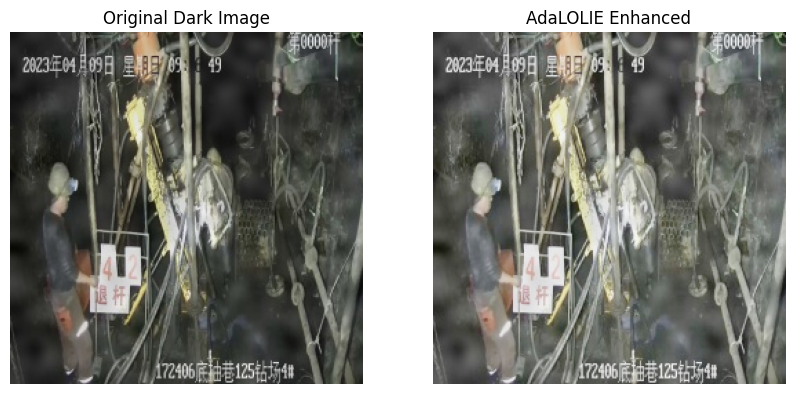

In [ ]:
import matplotlib.pyplot as plt
import cv2
import torch
import numpy as np
import os
from model_zero_dce_based import AdaLOLIE_Net

# 1. Load your newly trained model
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = AdaLOLIE_Net().to(device)
model.load_state_dict(torch.load("/content/drive/MyDrive/FYP_PROJECT/FYP_Checkpoints/AdaLOLIE_7/adalolie_best.pth", map_location=device)['model_state_dict'])
model.eval()

# 2. Load one of your dark YOLO test images
test_image_path = "/content/drive/MyDrive/FYP_PROJECT/RandomTestImages/test_image_1.jpg"

# Automatically create a save path in the same directory
save_path = test_image_path.replace(".jpg", "_enhanced.jpg")

raw_img = cv2.imread(test_image_path)
raw_rgb = cv2.cvtColor(raw_img, cv2.COLOR_BGR2RGB)
img_resized = cv2.resize(raw_rgb, (256, 256))

# 3. Enhance it
img_tensor = (img_resized / 255.0).astype(np.float32)
img_tensor = torch.from_numpy(img_tensor).permute(2, 0, 1).unsqueeze(0).to(device)

with torch.no_grad():
    enhanced_tensor, _ = model(img_tensor)

enhanced_np = enhanced_tensor.squeeze().permute(1, 2, 0).cpu().numpy()
enhanced_np = np.clip(enhanced_np, 0, 1)

# --- NEW: SAVE THE IMAGE TO GOOGLE DRIVE ---
# Convert from RGB float [0.0, 1.0] back to BGR integer [0, 255] for OpenCV
enhanced_bgr_for_saving = cv2.cvtColor((enhanced_np * 255).astype(np.uint8), cv2.COLOR_RGB2BGR)
cv2.imwrite(save_path, enhanced_bgr_for_saving)
print(f"💾 Successfully saved enhanced image to: {save_path}")
# ------------------------------------------

# 4. Show the Before and After
plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1)
plt.title("Original Dark Image")
plt.imshow(img_resized)
plt.axis('off')

plt.subplot(1, 2, 2)
plt.title("AdaLOLIE Enhanced")
plt.imshow(enhanced_np)
plt.axis('off')
plt.show()

### Universal Testing (1 GO)

In [ ]:
import matplotlib.pyplot as plt
import cv2
import torch
import numpy as np
from ultralytics import YOLO
from model_zero_dce_based import AdaLOLIE_Net

# 1. Load Models
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
enhancer = AdaLOLIE_Net().to(device)
# Update this path to new Run folder
enhancer.load_state_dict(torch.load("/content/drive/MyDrive/FYP_PROJECT/FYP_Checkpoints/AdaLOLIE_7/adalolie_best.pth", map_location=device)['model_state_dict'])
enhancer.eval()

yolo_model = YOLO("/content/drive/MyDrive/FYP_PROJECT/FYP_Checkpoints/YOLO_Runs/exp4_custom_sampling/weights/best.pt")

# 2. Load & CLAHE Preprocess
test_image_path = "/content/drive/MyDrive/FYP_PROJECT/RandomTestImages/test_image_2.jpg"
raw_img = cv2.imread(test_image_path)
raw_rgb = cv2.cvtColor(raw_img, cv2.COLOR_BGR2RGB)

# THE CLAHE STEP
lab = cv2.cvtColor(raw_rgb, cv2.COLOR_RGB2LAB)
l, a, b = cv2.split(lab)
clahe = cv2.createCLAHE(clipLimit=3.0, tileGridSize=(8,8))
l = clahe.apply(l)
lifted_rgb = cv2.cvtColor(cv2.merge((l, a, b)), cv2.COLOR_LAB2RGB)
# Feed YOLO's native resolution directly into AdaLOLIE
img_resized = cv2.resize(lifted_rgb, (640, 640))

# 3. Enhance
img_tensor = (img_resized / 255.0).astype(np.float32)
img_tensor = torch.from_numpy(img_tensor).permute(2, 0, 1).unsqueeze(0).to(device)

with torch.no_grad():
    enhanced_tensor, _ = enhancer(img_tensor)

enhanced_np = enhanced_tensor.squeeze().permute(1, 2, 0).cpu().numpy()
enhanced_np = np.clip(enhanced_np, 0, 1)

# 4. Save for YOLO
save_path = test_image_path.replace(".jpg", "_enhanced.jpg")
enhanced_bgr = cv2.cvtColor((enhanced_np * 255).astype(np.uint8), cv2.COLOR_RGB2BGR)
cv2.imwrite(save_path, enhanced_bgr)

# 5. YOLO Inference
results = yolo_model.predict(source=save_path, save=False, conf=0.15)
im_array = results[0].plot()
im_rgb = cv2.cvtColor(im_array, cv2.COLOR_BGR2RGB)

# 6. Visualize the entire pipeline
plt.figure(figsize=(15, 5))
plt.subplot(1, 3, 1)
plt.title("1. Original Dark")
plt.imshow(raw_rgb)
plt.axis('off')

plt.subplot(1, 3, 2)
plt.title("2. AdaLOLIE Enhanced")
plt.imshow(enhanced_np)
plt.axis('off')

plt.subplot(1, 3, 3)
plt.title("3. YOLO Detection")
plt.imshow(im_rgb)
plt.axis('off')
plt.show()

### Alpha Blending - Testing


image 1/1 /content/drive/MyDrive/FYP_PROJECT/RandomTestImages/test_image_3_enhanced_blended.jpg: 640x640 (no detections), 8.0ms
Speed: 1.7ms preprocess, 8.0ms inference, 0.6ms postprocess per image at shape (1, 3, 640, 640)


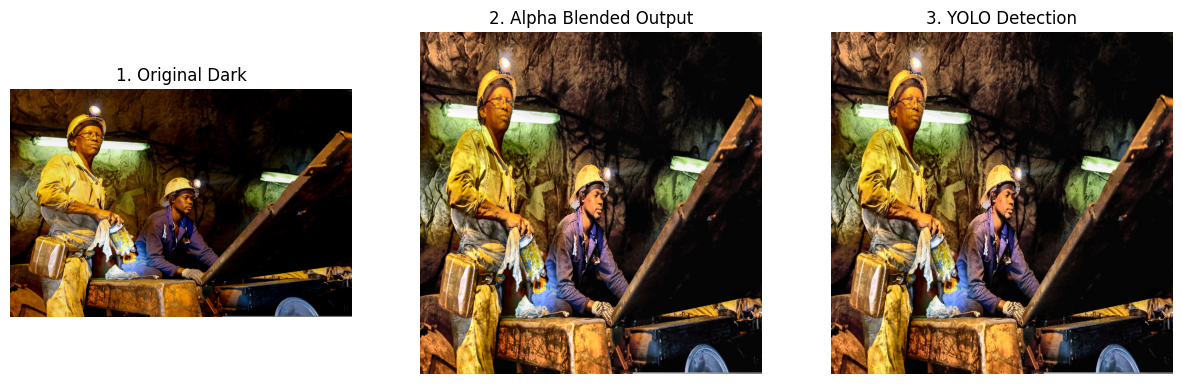

In [ ]:
import matplotlib.pyplot as plt
import cv2
import torch
import numpy as np
from ultralytics import YOLO
from model_zero_dce_based import AdaLOLIE_Net

# 1. Load Models
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
enhancer = AdaLOLIE_Net().to(device)
enhancer.load_state_dict(torch.load("/content/drive/MyDrive/FYP_PROJECT/FYP_Checkpoints/AdaLOLIE_9/adalolie_best.pth", map_location=device)['model_state_dict'])
enhancer.eval()

yolo_model = YOLO("/content/drive/MyDrive/FYP_PROJECT/FYP_Checkpoints/YOLO_Runs/exp4_custom_sampling/weights/best.pt")

# 2. Load & CLAHE Preprocess
test_image_path = "/content/drive/MyDrive/FYP_PROJECT/RandomTestImages/test_image_3.jpg"
raw_img = cv2.imread(test_image_path)
raw_rgb = cv2.cvtColor(raw_img, cv2.COLOR_BGR2RGB)

lab = cv2.cvtColor(raw_rgb, cv2.COLOR_RGB2LAB)
l, a, b = cv2.split(lab)
clahe = cv2.createCLAHE(clipLimit=3.0, tileGridSize=(8,8))
l = clahe.apply(l)
lifted_rgb = cv2.cvtColor(cv2.merge((l, a, b)), cv2.COLOR_LAB2RGB)
# Feed YOLO's native resolution directly into AdaLOLIE
img_resized = cv2.resize(lifted_rgb, (640, 640))

# 3. Enhance
img_tensor = (img_resized / 255.0).astype(np.float32)
img_tensor = torch.from_numpy(img_tensor).permute(2, 0, 1).unsqueeze(0).to(device)

with torch.no_grad():
    enhanced_tensor, _ = enhancer(img_tensor)

enhanced_np = enhanced_tensor.squeeze().permute(1, 2, 0).cpu().numpy()

# ALPHA BLENDIND
# Blend 60% of the AdaLOLIE brightness with 40% of the CLAHE texture/color
lifted_np = (img_resized / 255.0).astype(np.float32)
blended_np = (0.6 * enhanced_np) + (0.4 * lifted_np)
blended_np = np.clip(blended_np, 0, 1)
# -------------------------------

# 4. Save for YOLO (Now saving the BLENDED image)
save_path = test_image_path.replace(".jpg", "_enhanced_blended.jpg")
enhanced_bgr = cv2.cvtColor((blended_np * 255).astype(np.uint8), cv2.COLOR_RGB2BGR)
cv2.imwrite(save_path, enhanced_bgr)

# 5. YOLO Inference
results = yolo_model.predict(source=save_path, save=False, conf=0.15)
im_array = results[0].plot()
im_rgb = cv2.cvtColor(im_array, cv2.COLOR_BGR2RGB)

# 6. Visualize the entire pipeline
plt.figure(figsize=(15, 5))
plt.subplot(1, 3, 1)
plt.title("1. Original Dark")
plt.imshow(raw_rgb)
plt.axis('off')

plt.subplot(1, 3, 2)
plt.title("2. Alpha Blended Output")
plt.imshow(blended_np)
plt.axis('off')

plt.subplot(1, 3, 3)
plt.title("3. YOLO Detection")
plt.imshow(im_rgb)
plt.axis('off')
plt.show()